<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_or_gate_single_field.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def laplacian(Z):
    return (
        -4 * Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    )

def make_gate_field(a=0, b=0, size=100):
    Z = np.zeros((size, size), dtype=float)

    # ближче до центру
    if a == 1:
        Z[45:55, 35:45] = 1.0

    if b == 1:
        Z[45:55, 55:65] = 1.0

    return Z

In [ ]:
def diffuse_gate(Z, steps=220, diffusion=0.20, decay=0.010, reaction=0.55):
    Z = Z.copy()

    for _ in range(steps):
        L = laplacian(Z)

        center = Z[42:58, 42:58]
        center_signal = center.mean()

        # якщо дві хвилі зустрілись у центрі — підсилюємо
        gate_boost = np.zeros_like(Z)
        gate_boost[42:58, 42:58] = reaction * center_signal

        Z = Z + diffusion * L + gate_boost * Z - decay * Z
        Z = np.clip(Z, 0, 1)

    return Z

def detect_gate_state(Z):
    total_mass = float(Z.sum())
    center_mass = float(Z[40:60, 40:60].sum())
    max_value = float(Z.max())

    if total_mass < 1:
        return "EMPTY"

    if center_mass > 20 and max_value > 0.08:
        return "STABLE"

    return "DECAY"

A: 0 B: 0
STATE: EMPTY


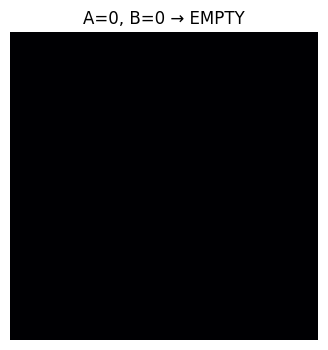

A: 1 B: 0
STATE: STABLE


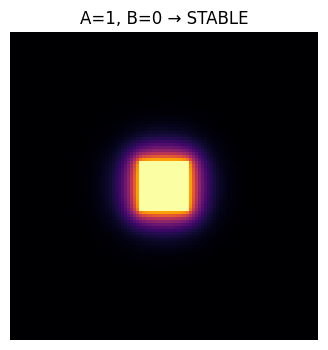

A: 0 B: 1
STATE: STABLE


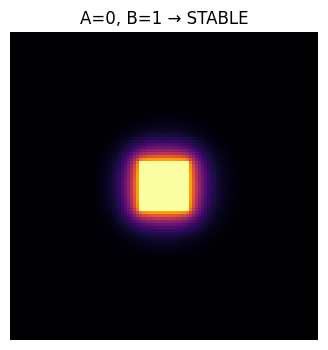

A: 1 B: 1
STATE: STABLE


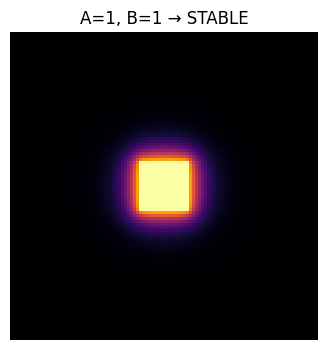

,A,B,state,mass,center,max
0,0,0,EMPTY,0.000,0.000,0.0
1,1,0,STABLE,529.260,350.840,1.0
2,0,1,STABLE,529.260,350.840,1.0
3,1,1,STABLE,535.972,351.032,1.0


In [ ]:
cases = [(0, 0), (1, 0), (0, 1), (1, 1)]
results = []

for a, b in cases:
    Z0 = make_gate_field(a, b)
    Z = diffuse_gate(Z0)
    state = detect_gate_state(Z)

    results.append({
        "A": a,
        "B": b,
        "state": state,
        "mass": round(float(Z.sum()), 3),
        "center": round(float(Z[40:60, 40:60].sum()), 3),
        "max": round(float(Z.max()), 3),
    })

    print("====================")
    print("A:", a, "B:", b)
    print("STATE:", state)

    plt.figure(figsize=(4, 4))
    plt.imshow(Z, cmap="inferno")
    plt.title(f"A={a}, B={b} → {state}")
    plt.axis("off")
    plt.show()

df = pd.DataFrame(results)
df